# NB16 — AutoGluon TimeSeries vs Tabular Forecasting

## Objective

This notebook performs a small methodological side experiment inside the existing Store Sales forecasting project.

The goal is not to build a new forecasting system and not to replace the NB1–NB15 pipeline.

The goal is to compare two forecasting paradigms on the same retail multi-series problem:

- Tabular feature-driven forecasting
- Native time-series forecasting

The reference tabular benchmark is NB9, where AutoGluon Tabular was evaluated on the validated advanced feature pipeline using recent walk-forward validation folds.

NB16 evaluates AutoGluon TimeSeries using the same dataset, same target, same forecasting horizon and same recent validation logic.

The key question is:

> On a retail multi-series forecasting problem, when is a tabular feature-driven approach preferable, and when is a native time-series approach preferable?

In [9]:
import warnings
warnings.filterwarnings("ignore")

import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor

sys.path.append(str(Path().resolve().parent))

from src.metrics import evaluate_regression

## Context

The main forecasting pipeline is already closed at NB15.

NB1–NB15 built a production-oriented forecasting prototype including:

- baseline modeling
- advanced feature engineering
- walk-forward validation
- AutoML benchmarking
- model inspection
- business-aware evaluation
- trust scoring
- monitoring and drift strategy

NB16 does not reopen that pipeline.

This notebook only adds a controlled methodological comparison between AutoGluon Tabular and AutoGluon TimeSeries.

The comparison reference is NB9 because NB9 represents the AutoGluon Tabular benchmark on the validated tabular feature pipeline.

In [10]:
SEED = 42

DATA_DIR = Path("../data")

ARTIFACTS_DIR = Path("../artifacts/nb16_autogluon_timeseries")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

MLFLOW_TRACKING_URI = "file:../mlruns"
MLFLOW_EXPERIMENT_NAME = "store_sales_forecasting"

PREDICTION_LENGTH = 28
TIME_LIMIT = 600
PRESETS = "medium_quality"

TARGET = "sales"

# Same recent fold logic used for the NB9 comparison.
# NB9 used two recent 28-day folds.
FOLDS = [
    {
        "fold": 1,
        "train_end": pd.Timestamp("2017-06-20"),
        "val_start": pd.Timestamp("2017-06-21"),
        "val_end": pd.Timestamp("2017-07-18"),
    },
    {
        "fold": 2,
        "train_end": pd.Timestamp("2017-07-18"),
        "val_start": pd.Timestamp("2017-07-19"),
        "val_end": pd.Timestamp("2017-08-15"),
    },
]

NB9_REFERENCE = {
    "model": "AutoGluon Tabular",
    "rmsle": 0.4761,
    "mae": 55.5435,
    "rmse": 201.0401,
    "r2": 0.9760,
}

print("Setup OK")
print("Data dir:", DATA_DIR.resolve())
print("Artifacts dir:", ARTIFACTS_DIR.resolve())
print("Prediction length:", PREDICTION_LENGTH)
print("Time limit:", TIME_LIMIT)

Setup OK
Data dir: /home/donatocorbacio/projects/store-sales-project/data
Artifacts dir: /home/donatocorbacio/projects/store-sales-project/artifacts/nb16_autogluon_timeseries
Prediction length: 28
Time limit: 600


## Load Data

We load the original Store Sales training dataset.

The target is `sales`.

Each time series is identified by the pair:

- `store_nbr`
- `family`

For AutoGluon TimeSeries, these two fields are combined into a single `item_id`.

In [11]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Train range:", train["date"].min(), "->", train["date"].max())
print("Test range:", test["date"].min(), "->", test["date"].max())

display(train.head())

Train shape: (3000888, 6)
Test shape: (28512, 5)
Train range: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


## Prepare AutoGluon TimeSeries Format

AutoGluon TimeSeries expects a panel time-series format with:

- `item_id`: unique identifier of each series
- `timestamp`: time index
- `target`: value to forecast

In this notebook:

- `item_id = store_nbr + family`
- `timestamp = date`
- `target = sales`

This is different from the tabular pipeline.

In NB9, the model received manually engineered lag, rolling and calendar features.

In NB16, the model receives the time-series structure directly.

In [12]:
df = train.copy()

df["item_id"] = df["store_nbr"].astype(str) + "_" + df["family"].astype(str)

ts_df = df.rename(columns={
    "date": "timestamp",
    "sales": "target",
})

ts_df = ts_df[[
    "item_id",
    "timestamp",
    "target",
    "onpromotion",
    "store_nbr",
    "family",
]].copy()

ts_df = ts_df.sort_values(["item_id", "timestamp"]).reset_index(drop=True)

print("TimeSeries dataframe shape:", ts_df.shape)
print("Number of series:", ts_df["item_id"].nunique())
print("Date range:", ts_df["timestamp"].min(), "->", ts_df["timestamp"].max())

display(ts_df.head())

TimeSeries dataframe shape: (3000888, 6)
Number of series: 1782
Date range: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00


,item_id,timestamp,target,onpromotion,store_nbr,family
0,10_AUTOMOTIVE,2013-01-01,0.0,0,10,AUTOMOTIVE
1,10_AUTOMOTIVE,2013-01-02,3.0,0,10,AUTOMOTIVE
2,10_AUTOMOTIVE,2013-01-03,2.0,0,10,AUTOMOTIVE
3,10_AUTOMOTIVE,2013-01-04,2.0,0,10,AUTOMOTIVE
4,10_AUTOMOTIVE,2013-01-05,0.0,0,10,AUTOMOTIVE


## Check Series Lengths

Before training a native time-series model, we verify that the panel structure is valid.

Each item should contain a sufficiently long historical sequence.

This matters because native time-series models learn from temporal sequences, not from independent tabular rows.

In [13]:
series_lengths = (
    ts_df.groupby("item_id")
    .size()
    .reset_index(name="n_observations")
)

display(series_lengths["n_observations"].describe())

print("Minimum series length:", series_lengths["n_observations"].min())
print("Maximum series length:", series_lengths["n_observations"].max())
print("Number of series:", len(series_lengths))

count    1782.0
mean     1684.0
std         0.0
min      1684.0
25%      1684.0
50%      1684.0
75%      1684.0
max      1684.0
Name: n_observations, dtype: float64

Minimum series length: 1684
Maximum series length: 1684
Number of series: 1782


## MLflow Setup

The experiment is tracked inside the same MLflow project used by the previous notebooks.

NB16 is tagged clearly as a methodological side experiment, not as a new production candidate.

In [14]:
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(MLFLOW_EXPERIMENT_NAME)

print("Active MLflow experiment:", MLFLOW_EXPERIMENT_NAME)

Active MLflow experiment: store_sales_forecasting


## Evaluation Helper

The forecast output is compared against the true validation horizon.

The same regression metrics are used for comparability:

- RMSLE
- MAE
- RMSE
- R²

RMSLE remains the main metric because it was used throughout the previous forecasting pipeline.

In [15]:
def prepare_fold_data(ts_df, fold_info):
    train_end = fold_info["train_end"]
    val_start = fold_info["val_start"]
    val_end = fold_info["val_end"]

    train_fold = ts_df[ts_df["timestamp"] <= train_end].copy()

    val_fold = ts_df[
        (ts_df["timestamp"] >= val_start) &
        (ts_df["timestamp"] <= val_end)
    ].copy()

    return train_fold, val_fold


def build_timeseries_frame(df):
    ts_data = TimeSeriesDataFrame.from_data_frame(
        df,
        id_column="item_id",
        timestamp_column="timestamp"
    )
    
    ts_data = ts_data.convert_frequency(freq="D")
    
    return ts_data


def evaluate_timeseries_predictions(val_fold, forecast_df, fold):
    forecast_reset = forecast_df.reset_index()

    # AutoGluon may return several columns depending on predictor settings.
    # The mean forecast is used as point prediction.
    if "mean" in forecast_reset.columns:
        pred_col = "mean"
    elif "0.5" in forecast_reset.columns:
        pred_col = "0.5"
    else:
        raise ValueError(f"No valid prediction column found. Columns: {forecast_reset.columns.tolist()}")

    preds = forecast_reset[["item_id", "timestamp", pred_col]].copy()
    preds = preds.rename(columns={pred_col: "prediction"})

    eval_df = val_fold.merge(
        preds,
        on=["item_id", "timestamp"],
        how="inner"
    )

    eval_df["prediction"] = eval_df["prediction"].clip(lower=0)

    metrics = evaluate_regression(
        eval_df["target"],
        eval_df["prediction"]
    )

    metrics["fold"] = fold

    eval_df["fold"] = fold
    eval_df["error"] = eval_df["target"] - eval_df["prediction"]
    eval_df["abs_error"] = np.abs(eval_df["error"])

    return metrics, eval_df

## Run AutoGluon TimeSeries Benchmark

For each fold:

1. Use all data up to the fold train cutoff
2. Train AutoGluon TimeSeries
3. Forecast the next 28 days
4. Compare predictions with the true validation horizon

This mirrors the NB9 validation logic while using a native time-series paradigm.

In [16]:
all_metrics = []
all_predictions = []

with mlflow.start_run(run_name="benchmark_autogluon_timeseries_nb16"):

    mlflow.set_tags({
        "project": "store_sales_forecasting",
        "notebook": "nb16",
        "experiment_type": "methodological_side_experiment",
        "benchmark_type": "autogluon_timeseries",
        "comparison_reference": "nb9_autogluon_tabular",
        "validation_strategy": "recent_walk_forward",
        "dataset_scope": "full_data",
        "production_candidate": "false",
        "model_registry": "false",
    })

    mlflow.log_params({
        "autogluon_model": "TimeSeriesPredictor",
        "prediction_length": PREDICTION_LENGTH,
        "time_limit_sec": TIME_LIMIT,
        "presets": PRESETS,
        "n_folds": len(FOLDS),
        "target": TARGET,
        "reference_nb9_rmsle": NB9_REFERENCE["rmsle"],
        "reference_nb9_mae": NB9_REFERENCE["mae"],
        "reference_nb9_rmse": NB9_REFERENCE["rmse"],
        "reference_nb9_r2": NB9_REFERENCE["r2"],
    })

    for fold_info in FOLDS:
        fold = fold_info["fold"]

        print("=" * 80)
        print(f"Fold {fold}")
        print("=" * 80)
        print("Train end:", fold_info["train_end"])
        print("Validation:", fold_info["val_start"], "->", fold_info["val_end"])

        train_fold, val_fold = prepare_fold_data(ts_df, fold_info)

        train_ts = build_timeseries_frame(train_fold)

        model_path = ARTIFACTS_DIR / "autogluon_timeseries_models" / f"fold_{fold}"

        predictor = TimeSeriesPredictor(
        prediction_length=PREDICTION_LENGTH,
        target="target",
        eval_metric="RMSE",
        freq="D",
        path=str(model_path),
        )

        start_time = time.time()

        predictor.fit(
            train_ts,
            presets=PRESETS,
            time_limit=TIME_LIMIT,
        )

        train_time = time.time() - start_time

        forecast_start = time.time()
        forecast = predictor.predict(train_ts)
        inference_time = time.time() - forecast_start

        metrics, fold_predictions = evaluate_timeseries_predictions(
            val_fold=val_fold,
            forecast_df=forecast,
            fold=fold,
        )

        metrics["train_time_sec"] = train_time
        metrics["inference_time_sec"] = inference_time

        all_metrics.append(metrics)
        all_predictions.append(fold_predictions)

        print(f"Fold {fold} metrics:")
        print(metrics)

        for metric_name, metric_value in metrics.items():
            if metric_name != "fold":
                mlflow.log_metric(f"fold_{fold}_{metric_name}", metric_value)

metrics_df = pd.DataFrame(all_metrics)
predictions_df = pd.concat(all_predictions, ignore_index=True)

display(metrics_df.head())
display(predictions_df.head())

Fold 1
Train end: 2017-06-20 00:00:00
Validation: 2017-06-21 00:00:00 -> 2017-07-18 00:00:00


Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/home/donatocorbacio/projects/store-sales-project/artifacts/nb16_autogluon_timeseries/autogluon_timeseries_models/fold_1'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025
CPU Count:          12
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       3.10 GB / 9.71 GB (31.9%)
Disk Space Avail:   933.62 GB / 1006.85 GB (92.7%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'freq': 'D',
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 28,
 'quantile_levels': [0.1, 0.2

config.json:   0%|          | 0.00/969 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/112M [00:00<?, ?B/s]

	Time limit exceeded... Skipping Chronos2.
Training timeseries model TemporalFusionTransformer. Training for up to 109.6s of the 219.3s of remaining time.
	-341.6072     = Validation score (-RMSE)
	100.95  s     = Training runtime
	4.16    s     = Validation (prediction) runtime
Fitting 1 ensemble(s), in 1 layers.
Training ensemble model WeightedEnsemble. Training for up to 113.9s.
	Ensemble weights: {'DirectTabular': 0.15, 'ETS': 0.08, 'RecursiveTabular': 0.69, 'TemporalFusionTransformer': 0.07}
	-264.9806     = Validation score (-RMSE)
	4.00    s     = Training runtime
	69.20   s     = Validation (prediction) runtime
Training complete. Models trained: ['SeasonalNaive', 'RecursiveTabular', 'DirectTabular', 'ETS', 'Theta', 'TemporalFusionTransformer', 'WeightedEnsemble']
Total runtime: 489.55 s
Best model: WeightedEnsemble
Best model score: -264.9806
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


Fold 1 metrics:
{'rmsle': 0.4149091056024637, 'mae': 55.84514127915286, 'rmse': 211.9997113091917, 'r2': 0.9743959590668196, 'fold': 1, 'train_time_sec': 492.00751996040344, 'inference_time_sec': 96.66186308860779}
Fold 2
Train end: 2017-07-18 00:00:00
Validation: 2017-07-19 00:00:00 -> 2017-08-15 00:00:00


Beginning AutoGluon training... Time limit = 600s
AutoGluon will save models to '/home/donatocorbacio/projects/store-sales-project/artifacts/nb16_autogluon_timeseries/autogluon_timeseries_models/fold_2'
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.3
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP PREEMPT_DYNAMIC Thu Jun  5 18:30:46 UTC 2025
CPU Count:          12
Pytorch Version:    2.9.1+cu128
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       2.35 GB / 9.71 GB (24.2%)
Disk Space Avail:   933.40 GB / 1006.85 GB (92.7%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'freq': 'D',
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 1,
 'prediction_length': 28,
 'quantile_levels': [0.1, 0.2

Fold 2 metrics:
{'rmsle': 0.47033842761717026, 'mae': 67.00293313142465, 'rmse': 240.16202298745262, 'r2': 0.9642700988793059, 'fold': 2, 'train_time_sec': 498.379070520401, 'inference_time_sec': 76.18997144699097}


,rmsle,mae,rmse,r2,fold,train_time_sec,inference_time_sec
0,0.414909,55.845141,211.999711,0.974396,1,492.007520,96.661863
1,0.470338,67.002933,240.162023,0.964270,2,498.379071,76.189971


,item_id,timestamp,target,onpromotion,store_nbr,family,prediction,fold,error,abs_error
0,10_AUTOMOTIVE,2017-06-21,1.0,0,10,AUTOMOTIVE,1.622112,1,-0.622112,0.622112
1,10_AUTOMOTIVE,2017-06-22,3.0,0,10,AUTOMOTIVE,1.634245,1,1.365755,1.365755
2,10_AUTOMOTIVE,2017-06-23,0.0,0,10,AUTOMOTIVE,2.558789,1,-2.558789,2.558789
3,10_AUTOMOTIVE,2017-06-24,1.0,0,10,AUTOMOTIVE,3.048128,1,-2.048128,2.048128
4,10_AUTOMOTIVE,2017-06-25,4.0,0,10,AUTOMOTIVE,3.908059,1,0.091941,0.091941


## Save NB16 Artifacts

The fold metrics and validation predictions are saved as artifacts.

These outputs can be reused later if needed, without retraining AutoGluon TimeSeries.

In [17]:
METRICS_PATH = ARTIFACTS_DIR / "nb16_autogluon_timeseries_fold_metrics.csv"
PREDICTIONS_PATH = ARTIFACTS_DIR / "nb16_autogluon_timeseries_predictions.csv"

metrics_df.to_csv(METRICS_PATH, index=False)
predictions_df.to_csv(PREDICTIONS_PATH, index=False)

print("Saved metrics:", METRICS_PATH)
print("Saved predictions:", PREDICTIONS_PATH)

Saved metrics: ../artifacts/nb16_autogluon_timeseries/nb16_autogluon_timeseries_fold_metrics.csv
Saved predictions: ../artifacts/nb16_autogluon_timeseries/nb16_autogluon_timeseries_predictions.csv


## AutoGluon TimeSeries Summary

The average metrics across folds are computed and compared with the NB9 AutoGluon Tabular reference.

Important:

This comparison is methodological.

NB9 uses a tabular feature-driven pipeline with engineered lag and rolling features.

NB16 uses a native time-series paradigm where the temporal structure is modeled directly.

In [18]:
summary_ts = pd.DataFrame([{
    "model": "AutoGluon TimeSeries",
    "rmsle_mean": metrics_df["rmsle"].mean(),
    "rmsle_std": metrics_df["rmsle"].std(),
    "mae_mean": metrics_df["mae"].mean(),
    "mae_std": metrics_df["mae"].std(),
    "rmse_mean": metrics_df["rmse"].mean(),
    "r2_mean": metrics_df["r2"].mean(),
    "train_time_mean_sec": metrics_df["train_time_sec"].mean(),
    "inference_time_mean_sec": metrics_df["inference_time_sec"].mean(),
    "n_folds": len(metrics_df),
    "prediction_length": PREDICTION_LENGTH,
    "time_limit_sec": TIME_LIMIT,
}])

display(summary_ts)

SUMMARY_PATH = ARTIFACTS_DIR / "nb16_autogluon_timeseries_summary.csv"
summary_ts.to_csv(SUMMARY_PATH, index=False)

print("Saved summary:", SUMMARY_PATH)

,model,rmsle_mean,rmsle_std,mae_mean,mae_std,rmse_mean,r2_mean,train_time_mean_sec,inference_time_mean_sec,n_folds,prediction_length,time_limit_sec
0,AutoGluon TimeSeries,0.442624,0.039194,61.424037,7.88975,226.080867,0.969333,495.193295,86.425917,2,28,600


Saved summary: ../artifacts/nb16_autogluon_timeseries/nb16_autogluon_timeseries_summary.csv


In [19]:
comparison_df = pd.DataFrame([
    {
        "model": "NB9_AutoGluon_Tabular",
        "paradigm": "tabular_feature_driven",
        "rmsle": NB9_REFERENCE["rmsle"],
        "mae": NB9_REFERENCE["mae"],
        "rmse": NB9_REFERENCE["rmse"],
        "r2": NB9_REFERENCE["r2"],
        "notes": "Validated tabular AutoML benchmark with engineered features",
    },
    {
        "model": "NB16_AutoGluon_TimeSeries",
        "paradigm": "native_time_series",
        "rmsle": summary_ts.loc[0, "rmsle_mean"],
        "mae": summary_ts.loc[0, "mae_mean"],
        "rmse": summary_ts.loc[0, "rmse_mean"],
        "r2": summary_ts.loc[0, "r2_mean"],
        "notes": "Native multi-series forecasting approach",
    }
])

display(comparison_df)

COMPARISON_PATH = ARTIFACTS_DIR / "nb16_tabular_vs_timeseries_comparison.csv"
comparison_df.to_csv(COMPARISON_PATH, index=False)

print("Saved comparison:", COMPARISON_PATH)

,model,paradigm,rmsle,mae,rmse,r2,notes
0,NB9_AutoGluon_Tabular,tabular_feature_driven,0.476100,55.543500,201.040100,0.976000,Validated tabular AutoML benchmark with engine...
1,NB16_AutoGluon_TimeSeries,native_time_series,0.442624,61.424037,226.080867,0.969333,Native multi-series forecasting approach


Saved comparison: ../artifacts/nb16_autogluon_timeseries/nb16_tabular_vs_timeseries_comparison.csv


## Metric Comparison

The following plots compare NB9 AutoGluon Tabular and NB16 AutoGluon TimeSeries on the main evaluation metrics.

The goal is not only to identify which approach scores better, but to reason about what each paradigm offers operationally.

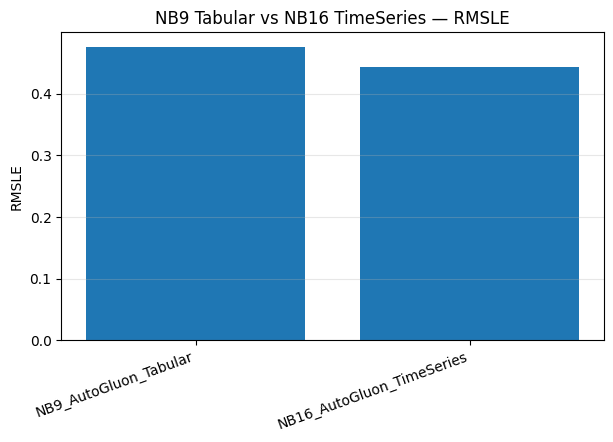

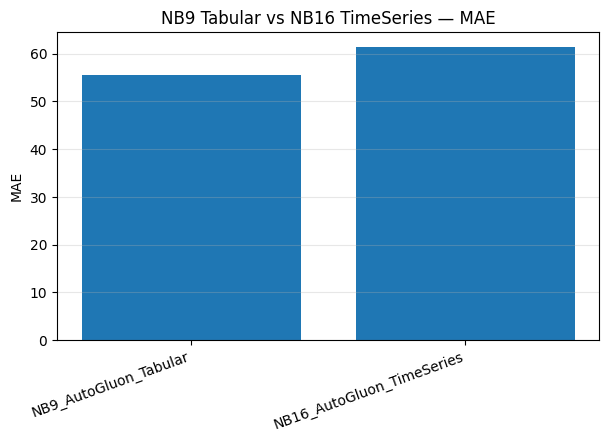

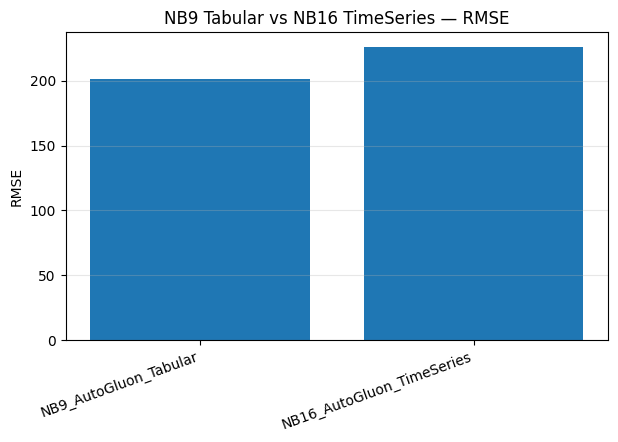

In [20]:
plot_df = comparison_df.copy()

for metric in ["rmsle", "mae", "rmse"]:
    plt.figure(figsize=(7, 4))
    plt.bar(plot_df["model"], plot_df[metric])
    plt.title(f"NB9 Tabular vs NB16 TimeSeries — {metric.upper()}")
    plt.ylabel(metric.upper())
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

## Paradigm Comparison

The comparison between AutoGluon Tabular and AutoGluon TimeSeries should not be interpreted only as a metric race.

The two approaches solve the same forecasting problem with different assumptions.

### Tabular feature-driven forecasting

The tabular approach transforms forecasting into supervised regression.

Strengths:

- high control over features
- explicit lag and rolling logic
- strong integration with business variables
- easier feature inspection
- easier debugging
- strong performance when engineered features are good

Weaknesses:

- feature engineering effort is higher
- leakage risks must be managed carefully
- recursive multi-step forecasting can become more complex
- the temporal structure is not modeled natively

### Native time-series forecasting

The native time-series approach models each series as a temporal sequence.

Strengths:

- forecasting horizon is handled directly
- less manual feature engineering
- natural fit for multi-series forecasting
- cleaner conceptual forecasting setup
- useful when many related series share temporal behavior

Weaknesses:

- less direct control over engineered signals
- model behavior can be harder to inspect
- business-specific covariates require careful handling
- performance depends heavily on how well the native model captures the panel structure

## Final Conclusion

NB16 confirms that the project can be interpreted through two forecasting paradigms:

1. Tabular feature-driven forecasting
2. Native time-series forecasting

The tabular approach used in NB9 remains a strong reference because it combines:

- engineered temporal signals
- business features
- AutoML model selection
- strong empirical performance

The native TimeSeries approach is useful because it provides a cleaner forecasting-native workflow:

- direct multi-step forecasting
- less manual feature construction
- natural treatment of multiple related time series

The practical conclusion is not that one paradigm always dominates the other.

The right choice depends on the production context.

Use a tabular feature-driven approach when:

- business covariates are important
- interpretability and feature control matter
- the team wants to debug specific failure modes
- engineered lag and rolling features are reliable
- the model must be integrated into an existing tabular ML pipeline

Use a native time-series approach when:

- the forecasting horizon should be modeled directly
- many related series must be forecast together
- rapid forecasting prototyping is needed
- the objective is to reduce manual feature engineering
- the team prefers a forecasting-native abstraction

In this project, NB16 acts as a methodological extension of the existing production-oriented forecasting prototype.

It does not replace NB1–NB15.

It adds a controlled comparison that helps explain when and why a Machine Learning Engineer might choose one forecasting paradigm over another.